In [20]:
import pandas as pd

In [21]:
data = pd.read_csv("../Pattern Recognition.txt", delimiter=", ")
data = data.iloc[625:].reset_index(drop=True)

C:\Users\Alyssa\AppData\Local\Temp\ipykernel_10756\2606540513.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv("../Pattern Recognition.txt", delimiter=", ")


In [22]:
channel_mapping = {
    'EXG Channel 0': 'Channel_1',
    'EXG Channel 1': 'Channel_2',
    'EXG Channel 2': 'Channel_5',
    'EXG Channel 3': 'Channel_6',
    'EXG Channel 4': 'Channel_10',
    'EXG Channel 5': 'Channel_11',
    'EXG Channel 6': 'Channel_23',
    'EXG Channel 7': 'Channel_24',
    'EXG Channel 8': 'Channel_27',
    'EXG Channel 9': 'Channel_28',
    'EXG Channel 10': 'Channel_8',
    'EXG Channel 11': 'Channel_9',
    'EXG Channel 12': 'Channel_16',
    'EXG Channel 13': 'Channel_17',
    'EXG Channel 14': 'Channel_21',
    'EXG Channel 15': 'Channel_22'
}

data = data.rename(columns=channel_mapping)
data = data[list(channel_mapping.values())]

In [23]:
print(data)

           Channel_1      Channel_2      Channel_5      Channel_6  \
0     -111084.079574 -110461.739953 -111402.435470 -111229.589430   
1     -108717.655685 -108097.439480 -109037.710314 -108856.750590   
2     -111651.568014 -111033.519928 -111975.757715 -111789.567684   
3     -109202.822650 -108579.834828 -109520.865622 -109349.561852   
4     -110069.802114 -109451.731676 -110393.500077 -110204.449022   
...              ...            ...            ...            ...   
10777  -83165.119072  -82720.654633  -83566.869326  -83385.596679   
10778  -83157.921810  -82707.712973  -83555.581696  -83391.162263   
10779  -81712.076868  -81265.332552  -82111.323728  -81936.041348   
10780  -84376.516566  -83930.755726  -84777.640972  -84604.593766   
10781  -81783.378933  -81333.974759  -82180.658839  -82014.227750   

          Channel_10     Channel_11     Channel_23     Channel_24  \
0     -110612.346007 -111315.330722 -110773.479733 -110484.471677   
1     -108243.239909 -108944.9282

In [24]:
from scipy.signal import iirnotch, filtfilt

# Parameter
fs = 250       # Sampling rate (Hz)
f0 = 50        # Frekuensi listrik (Hz)
quality_factor = 30

# Notch Filter
nyquist = 0.5 * fs
freq = f0 / nyquist
b, a = iirnotch(freq, quality_factor)

notch_filtered = data.copy()
for col in data.columns:
    notch_filtered[col] = filtfilt(b, a, data[col].values)

print("✓ Notch filter applied (50 Hz)")
print(notch_filtered.head())

✓ Notch filter applied (50 Hz)
       Channel_1      Channel_2      Channel_5      Channel_6     Channel_10  \
0 -111078.002702 -110455.742361 -111396.427232 -111223.372598 -110606.248700   
1 -108741.754843 -108121.460913 -109061.684116 -108881.150872 -108267.456466   
2 -111671.609329 -111053.436347 -111995.653547 -111809.929285 -111196.949052   
3 -109192.723045 -108569.732730 -109510.797976 -109339.363326 -108720.728043   
4 -110044.471241 -109426.518169 -110368.329114 -110178.746453 -109569.327857   

      Channel_11     Channel_23     Channel_24     Channel_27     Channel_28  \
0 -111309.114905 -110767.165416 -110477.864490 -111542.637582 -111714.042819   
1 -108969.154330 -108422.929500 -108130.867999 -109299.250307 -109413.298178   
2 -111898.941931 -111344.571994 -111037.258798 -110094.721793 -110269.724756   
3 -109424.385908 -108885.549804 -108606.300284 -110978.872406 -111114.160336   
4 -110269.099614 -109713.099982 -109402.022538 -108488.962610 -108624.297483   

       

In [25]:
from scipy.signal import butter

# Parameter
lowcut = 0.5   # Hz
highcut = 49.5   # Hz
order = 5

# Bandpass Filter
nyq = 0.5 * fs
low = lowcut / nyq
high = highcut / nyq
b, a = butter(order, [low, high], btype='band')

bandpass_filtered = notch_filtered.copy()
for col in notch_filtered.columns:
    bandpass_filtered[col] = filtfilt(b, a, notch_filtered[col].values)

print("✓ Bandpass filter applied (0.5 - 49.5 Hz)")
print(bandpass_filtered.head())

✓ Bandpass filter applied (0.5 - 49.5 Hz)
     Channel_1    Channel_2    Channel_5    Channel_6   Channel_10  \
0   198.038613   199.097248   201.082606   196.974129   198.746710   
1   894.775607   894.178476   895.867969   897.450195   897.212686   
2  1258.080224  1256.712495  1258.151712  1262.613309  1261.357755   
3  1258.120931  1256.951292  1258.160372  1262.501277  1261.241937   
4  1125.583629  1124.983442  1125.907725  1129.167475  1128.163608   

    Channel_11   Channel_23   Channel_24   Channel_27   Channel_28  \
0   198.064089   194.745886   188.822664  -466.815117  -464.322659   
1   896.951867   898.247204   897.246526   651.850881   673.753004   
2  1261.424342  1265.012543  1266.641590  1231.438129  1263.222971   
3  1261.500661  1264.812630  1266.497603  1223.260490  1254.422139   
4  1128.468072  1130.551337  1131.229108   999.821795  1026.323346   

     Channel_8    Channel_9   Channel_16   Channel_17   Channel_21  Channel_22  
0  -457.446139  -459.556280  -458.5

In [26]:
import numpy as np
from scipy.signal import welch

# Parameter windowing
# window_size = 250  # 1 detik (250 samples @ 250Hz)
window_size = 1250  # 5 detik (250 samples @ 250Hz)
step_size = 250    # tanpa overlap

# Hitung PSD per window per channel
psd_results = []

num_samples = len(bandpass_filtered)
num_windows = num_samples // window_size

for w in range(num_windows):
    start = w * window_size
    end = start + window_size
    window_psd = {}
    
    for col in bandpass_filtered.columns:
        segment = bandpass_filtered[col].values[start:end]
        freqs, psd = welch(segment, fs=fs, nperseg=window_size)
        window_psd[f'{col}_PSD'] = np.mean(psd)
    
    psd_results.append(window_psd)

psd_df = pd.DataFrame(psd_results)

print(f"✓ PSD dihitung: {len(psd_df)} windows, {len(psd_df.columns)} channels")
print(f"  Shape: {psd_df.shape}\n")
print(psd_df.head())

✓ PSD dihitung: 8 windows, 16 channels
  Shape: (8, 16)

   Channel_1_PSD  Channel_2_PSD  Channel_5_PSD  Channel_6_PSD  Channel_10_PSD  \
0      69.237000      68.854759      69.406626      68.529686       69.224719   
1       3.769908       3.703814       3.973235       4.202001        3.959561   
2       5.501972       6.690787       5.507636       5.834493        5.499303   
3     134.918463     135.636974     138.720645     138.317030      137.622457   
4       9.677090       9.364704       9.209832       9.273569        9.233652   

   Channel_11_PSD  Channel_23_PSD  Channel_24_PSD  Channel_27_PSD  \
0       68.971442       69.296580       69.493934       77.026267   
1        3.866648        3.935671        3.943135        4.080642   
2        5.607118        5.512572        5.572325        5.536275   
3      137.560947      137.908522      137.772524      137.551271   
4        9.293779        9.120942        9.113890        9.228190   

   Channel_28_PSD  Channel_8_PSD  Channel

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
psd_scaled = pd.DataFrame(
    scaler.fit_transform(psd_df),
    columns=psd_df.columns
)

print(f"✓ Scaling 0-1 applied")
print(f"  Min: {psd_scaled.min().min():.6f}")
print(f"  Max: {psd_scaled.max().max():.6f}\n")
print(psd_scaled.head())

✓ Scaling 0-1 applied
  Min: 0.000000
  Max: 1.000000

   Channel_1_PSD  Channel_2_PSD  Channel_5_PSD  Channel_6_PSD  Channel_10_PSD  \
0       0.262218       0.259662       0.255806       0.251315        0.253450   
1       0.007850       0.005769       0.006836       0.006322        0.005790   
2       0.014580       0.017409       0.012674       0.012539        0.011633   
3       0.517418       0.519913       0.519543       0.517101        0.512997   
4       0.030802       0.027830       0.026761       0.025637        0.025804   

   Channel_11_PSD  Channel_23_PSD  Channel_24_PSD  Channel_27_PSD  \
0        0.254103        0.255632        0.255882        0.280132   
1        0.005783        0.006586        0.005839        0.005164   
2        0.012422        0.012594        0.012054        0.010651   
3        0.515715        0.517066        0.516329        0.508280   
4        0.026483        0.026343        0.025563        0.024568   

   Channel_28_PSD  Channel_8_PSD  Channel_9

In [28]:
output_path = r"E:\eeg-analysis\Pattern_Recognition_PSD.csv"
psd_scaled.to_csv(output_path, index=False)

print(f"✓ CSV disimpan: {output_path}")
print(f"  Shape: {psd_scaled.shape}")

✓ CSV disimpan: E:\eeg-analysis\Pattern_Recognition_PSD.csv
  Shape: (8, 16)


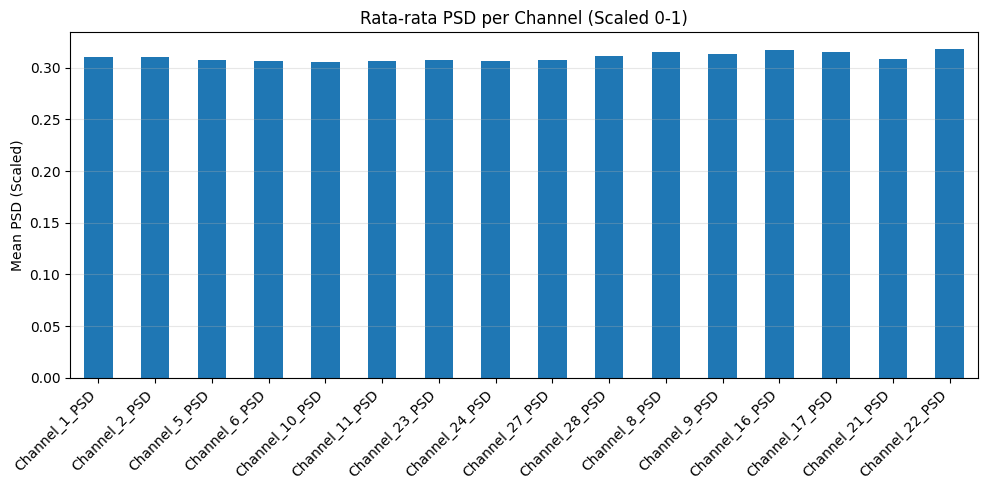

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
psd_scaled.mean().plot(kind='bar')
plt.title("Rata-rata PSD per Channel (Scaled 0-1)")
plt.ylabel("Mean PSD (Scaled)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()